# Download Input Data and Run Forecast for Zeynep 

This section performs a one-step forecast for Storm Zeynep, targeting 22:00 UTC on 2022-02-18. Accordingly, the input data includes observations from 10:00 and 16:00 UTC on the same day.

Data is stored locally and optionally uploaded to a Google Cloud Storage (GCS) bucket if upload_to_gcs=True.


### Checkpoint Requirements

Each forecast model variant requires a specific configuration of input data (here, GraphCast_small is used):

- GraphCast_small: 13 pressure levels, 1.0° resolution

- GraphCast_operational: 13 pressure levels, 0.25° resolution

- GraphCast: 37 pressure levels, 0.25° resolution


In [1]:
import xarray as xr

from pkg.forecast.input_preparation import prepare_graphcast_input
from pkg.forecast.run_forecast import run_forecast
from pkg.plots.forecast_plots import plot_wind_speed_comparison, evaluate_wind_prediction

## Download Data for GraphCast

Data is downloaded from the ERA5 database and prepared to be a suitable input for GraphCast. 

In [2]:
output_folder = "../data/graphcast_small"
name_input = "graphcast_small_zeynep_input"
name_output = "graphcast_small_zeynep_prediction"

In [ ]:
# GraphCast_small for forecast 22:00 UTC on 18th February 2022
prepare_graphcast_input(
    date="2022-02-18",
    start_time="10:00",
    n_steps=3,
    levels=13,
    resolution=1.0,
    output_folder=output_folder,
    name=name_input,
    upload_to_gcs=True
)

## Run Forecast

In [3]:
# Open the input file
input_ds = xr.open_dataset(f"{output_folder}/{name_input}/graphcast_ready_input_{name_input}.nc")

In [ ]:
# Run forecast for GraphCast_small
run_forecast(
    model_name="graphcast_small",
    input_data_or_path=input_ds,
    output_name=name_output,
    predictions_folder=output_folder,
    upload_to_gcs=True
)

## Compare Prediction to ERA5-Reanalysis Data

In [5]:
# Open the prediction file
prediction_ds = xr.open_dataset(f"{output_folder}/{name_output}.nc")

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_95991/1461811897.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  prediction_ds = xr.open_dataset(f"{output_folder}/{name_output}.nc")


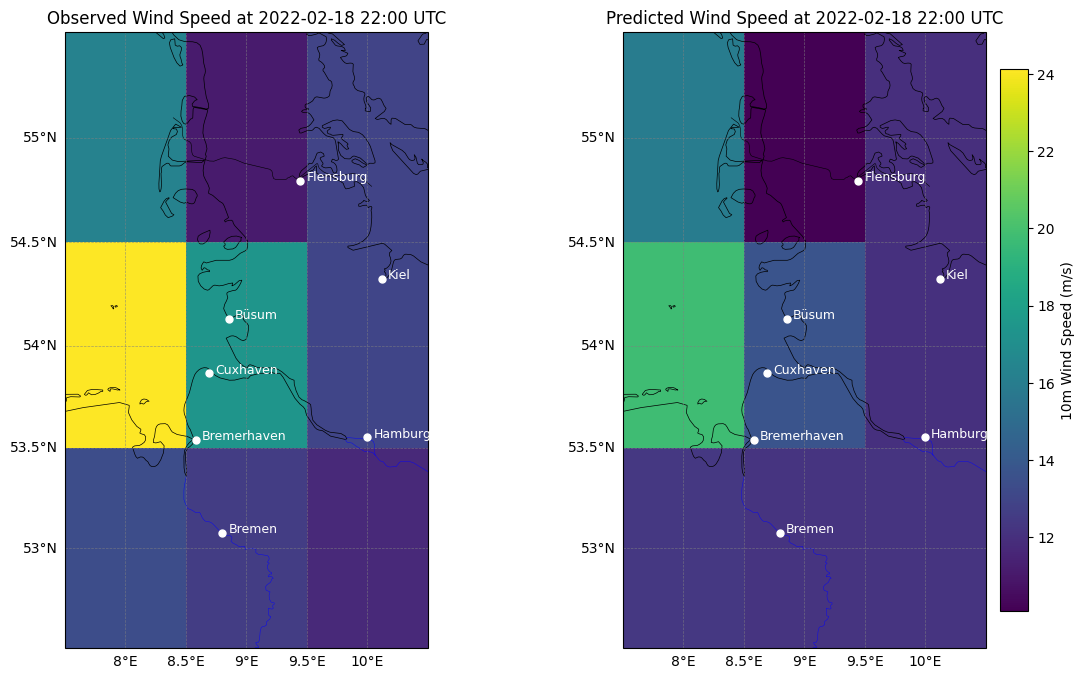

In [ ]:
# Evaluate the wind speed prediction in northern Germany

plot_wind_speed_comparison(
    prediction=prediction_ds,
    input_data=input_ds,
    lon_min=7.5,
    lon_max=10.5,
    lat_min=52.5,
    lat_max=55.5,
    time_label="2022-02-18 22:00 UTC"
)

## Diagnostics of Prediction

In [ ]:
# Evaluation for average of northern Germany

evaluate_wind_prediction(
    era5_data=input_ds,
    prediction_data=prediction_ds,
    region_lat=(55.0, 53.0),
    region_lon=(8.0, 10.0)
)

✅ Mean Absolute Error (MAE):  1.47 m/s
✅ Root Mean Square Error (RMSE): 2.03 m/s
📏 Grid: 3 lat × 3 lon = 9 points


{'mae': 1.4699511528015137,
 'rmse': 2.0302248001098633,
 'lat_points': 3,
 'lon_points': 3,
 'total_points': 9}